# Analysis of Cryptocurrency and Financial Markets

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf
from scipy import stats
from statsmodels.tsa.api import VAR

# 设置绘图风格和中文字体
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = [
    "PingFang SC",
    "Heiti SC",
    "STHeiti",
    "SimHei",
    "Arial Unicode MS",
]
plt.rcParams["axes.unicode_minus"] = False

## 重新加载数据

In [3]:
duckdb.execute(
    """
create or replace table btc_raw as (
    select *,'btc' as coin_name
    from read_csv_auto(
    'data/crypto/btcusd.csv',
    header=true,
    columns={'time': 'BIGINT', 'open': 'DOUBLE', 'high': 'DOUBLE', 'low': 'DOUBLE', 'close': 'DOUBLE', 'volume': 'DOUBLE'}
    )
)
"""
)
duckdb.execute(
    """
create or replace table eth_raw as (
    select *,'eth' as coin_name
    from read_csv_auto(
    'data/crypto/ethusd.csv',
    header=true,
    columns={'time': 'BIGINT', 'open': 'DOUBLE', 'high': 'DOUBLE', 'low': 'DOUBLE', 'close': 'DOUBLE', 'volume': 'DOUBLE'}
    )
)
"""
)
duckdb.execute(
    """
create or replace table ltc_raw as (
    select *,'ltc' as coin_name
    from read_csv_auto(
    'data/crypto/ltcusd.csv',
    header=true,
    columns={'time': 'BIGINT', 'open': 'DOUBLE', 'high': 'DOUBLE', 'low': 'DOUBLE', 'close': 'DOUBLE', 'volume': 'DOUBLE'}
  )
  )
  """
)
duckdb.execute("""
    CREATE OR REPLACE TABLE crypto_data as (
        SELECT *, 'btc' as coin_name from btc_raw
        UNION ALL
        SELECT *, 'eth' as coin_name from eth_raw
        UNION ALL 
        SELECT *, 'ltc' as coin_name from ltc_raw
    );
""")
duckdb.query(
    "select date_trunc('hour', to_timestamp(time / 1000)) AS time_bucket, coin_name,arg_min(open, to_timestamp(time / 1000)) AS open,arg_max(close, to_timestamp(time / 1000)) AS close,sum(volume) AS volume, max(high), min(low) from crypto_data group by 1,2"
)
# 1. 执行您的聚合查询，并用 .to_df() 转换为 Pandas DataFrame
query = """
SELECT 
    date_trunc('hour', to_timestamp(time / 1000)) AS time_bucket, 
    coin_name,
    arg_min(open, to_timestamp(time / 1000)) AS open,
    max(high) AS high,
    min(low) AS low,
    arg_max(close, to_timestamp(time / 1000)) AS close,
    sum(volume) AS volume
FROM 
    crypto_data 
GROUP BY 
    1, 2
ORDER BY
    1, 2;
"""
hourly_df = duckdb.query(query).to_df()

# 2. 检查数据
print("数据已加载到 DataFrame，前几行如下：")
print(hourly_df.head())

print("\n数据信息：")
hourly_df.info()

数据已加载到 DataFrame，前几行如下：
                time_bucket coin_name      open       high       low  \
0 2013-04-01 08:00:00+08:00       btc  93.25000  100.00000  93.03001   
1 2013-04-01 09:00:00+08:00       btc  93.37999   93.48797  93.10001   
2 2013-04-01 10:00:00+08:00       btc  93.17000   93.74000  93.10999   
3 2013-04-01 11:00:00+08:00       btc  93.80000   93.80000  92.50000   
4 2013-04-01 12:00:00+08:00       btc  93.15501   93.15503  93.15503   

      close      volume  
0  93.10000  345.583889  
1  93.10000   45.243335  
2  93.74000  466.311420  
3  92.70002   96.316180  
4  93.15501    5.000000  

数据信息：
<class 'pandas.DataFrame'>
RangeIndex: 235402 entries, 0 to 235401
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype                        
---  ------       --------------   -----                        
 0   time_bucket  235402 non-null  datetime64[us, Asia/Shanghai]
 1   coin_name    235402 non-null  str                          
 2   open         235

In [4]:
# 准备加密货币数据
# hourly_df 是“长格式”数据。为了与每日宏观数据合并，我们需要：
# 1. 将其聚合到“每日”级别。
# 2. 将其从“长格式”转换为“宽格式”（即每个币种有自己的列）。

print("\n[步骤1] 正在将每小时加密数据聚合为每日数据...")

# 确保 time_bucket 是 datetime 类型并设为索引
hourly_df["time_bucket"] = pd.to_datetime(hourly_df["time_bucket"])
hourly_df.set_index("time_bucket", inplace=True)

# 按币种分组，然后按天 (D) 重新采样
daily_crypto_df = (
    hourly_df.groupby("coin_name")
    .resample("D")
    .agg(
        daily_close=("close", "last"),  # 每日收盘价 = 当天最后一个有效小时的收盘价
        daily_volume=("volume", "sum"),  # 每日总交易量 = 当天所有小时交易量之和
    )
    .dropna()
    .reset_index()
)

# 使用 pivot 将长格式转换为宽格式
print("正在进行数据透视 (pivot) 操作...")
daily_crypto_pivot = daily_crypto_df.pivot(
    index="time_bucket", columns="coin_name", values=["daily_close", "daily_volume"]
)

# 清理列名，例如从 ('daily_close', 'btc') 变为 'BTC_close'
daily_crypto_pivot.columns = [
    f"{coin.upper()}_{metric.replace('daily_', '')}"
    for metric, coin in daily_crypto_pivot.columns
]

print("每日加密数据准备完毕：")
print(daily_crypto_pivot.head())


[步骤1] 正在将每小时加密数据聚合为每日数据...
正在进行数据透视 (pivot) 操作...
每日加密数据准备完毕：
                            BTC_close  ETH_close  LTC_close    BTC_volume  \
time_bucket                                                                 
2013-04-01 00:00:00+08:00  102.200000        NaN        NaN   3980.346741   
2013-04-02 00:00:00+08:00  107.099885        NaN        NaN   6005.973891   
2013-04-03 00:00:00+08:00  130.000000        NaN        NaN  10432.897488   
2013-04-04 00:00:00+08:00  135.000000        NaN        NaN  11110.603022   
2013-04-05 00:00:00+08:00  137.313000        NaN        NaN   5941.530401   

                           ETH_volume  LTC_volume  
time_bucket                                        
2013-04-01 00:00:00+08:00         NaN         NaN  
2013-04-02 00:00:00+08:00         NaN         NaN  
2013-04-03 00:00:00+08:00         NaN         NaN  
2013-04-04 00:00:00+08:00         NaN         NaN  
2013-04-05 00:00:00+08:00         NaN         NaN  


## 获取宏观经济数据

我们分析以下几个经济指标：标普500指数，纳斯达克综合指数，VIX恐慌指数，黄金期货，美元指数。

In [5]:
# --- 步骤2: 使用yfinance获取宏观经济数据 ---

print("\n[步骤2] 正在从雅虎财经下载宏观经济数据...")

# 定义我们感兴趣的经济指标 Tickers
tickers = {
    "^GSPC": "SP500",  # 标普500指数
    "^IXIC": "NASDAQ",  # 纳斯达克综合指数
    "^VIX": "VIX",  # VIX恐慌指数
    "GC=F": "Gold",  # 黄金期货
    "DX-Y.NYB": "USD_Index",  # 美元指数
}

# 动态获取与您的数据匹配的日期范围
start_date = daily_crypto_pivot.index.min().strftime("%Y-%m-%d")
end_date = daily_crypto_pivot.index.max().strftime("%Y-%m-%d")

print(f"下载时间范围: {start_date} 到 {end_date}")

# 下载数据
eco_data = yf.download(
    list(tickers.keys()), start=start_date, end=end_date, progress=False
)

# 我们只关心收盘价 'Close'，并重命名为更友好的名称
eco_close_data = eco_data["Close"].rename(columns=tickers)

# 经济数据在周末或节假日没有数据，会产生NaN。我们使用前向填充(ffill)来填补空白。
eco_close_data = eco_close_data.ffill().bfill()

print("宏观经济数据下载并处理完毕：")
print(eco_close_data.head())


# --- 步骤3: 合并所有数据到一个DataFrame ---

print("\n[步骤3] 正在合并加密数据和宏观经济数据...")
daily_crypto_pivot.index = daily_crypto_pivot.index.tz_localize(None)
# 使用 'inner' join 来确保只分析所有数据源都存在的日期
merged_df = pd.merge(
    daily_crypto_pivot, eco_close_data, left_index=True, right_index=True, how="inner"
)

print("数据合并完成。最终DataFrame预览：")
print(merged_df.head())


[步骤2] 正在从雅虎财经下载宏观经济数据...
下载时间范围: 2013-04-01 到 2023-10-08
宏观经济数据下载并处理完毕：
Ticker      USD_Index         Gold        SP500       NASDAQ    VIX
Date                                                               
2013-04-01  82.730003  1600.000000  1562.170044  3239.169922  13.58
2013-04-02  82.940002  1575.099976  1570.250000  3254.860107  12.78
2013-04-03  82.720001  1552.800049  1553.689941  3218.600098  14.21
2013-04-04  82.680000  1551.800049  1559.979980  3224.979980  13.89
2013-04-05  82.500000  1575.400024  1553.280029  3203.860107  13.92

[步骤3] 正在合并加密数据和宏观经济数据...
数据合并完成。最终DataFrame预览：
              BTC_close  ETH_close  LTC_close    BTC_volume  ETH_volume  \
time_bucket                                                               
2013-04-01   102.200000        NaN        NaN   3980.346741         NaN   
2013-04-02   107.099885        NaN        NaN   6005.973891         NaN   
2013-04-03   130.000000        NaN        NaN  10432.897488         NaN   
2013-04-04   135.000000     

## 进行关联分析


[步骤4] 正在计算每日收益率并生成可视化图表...


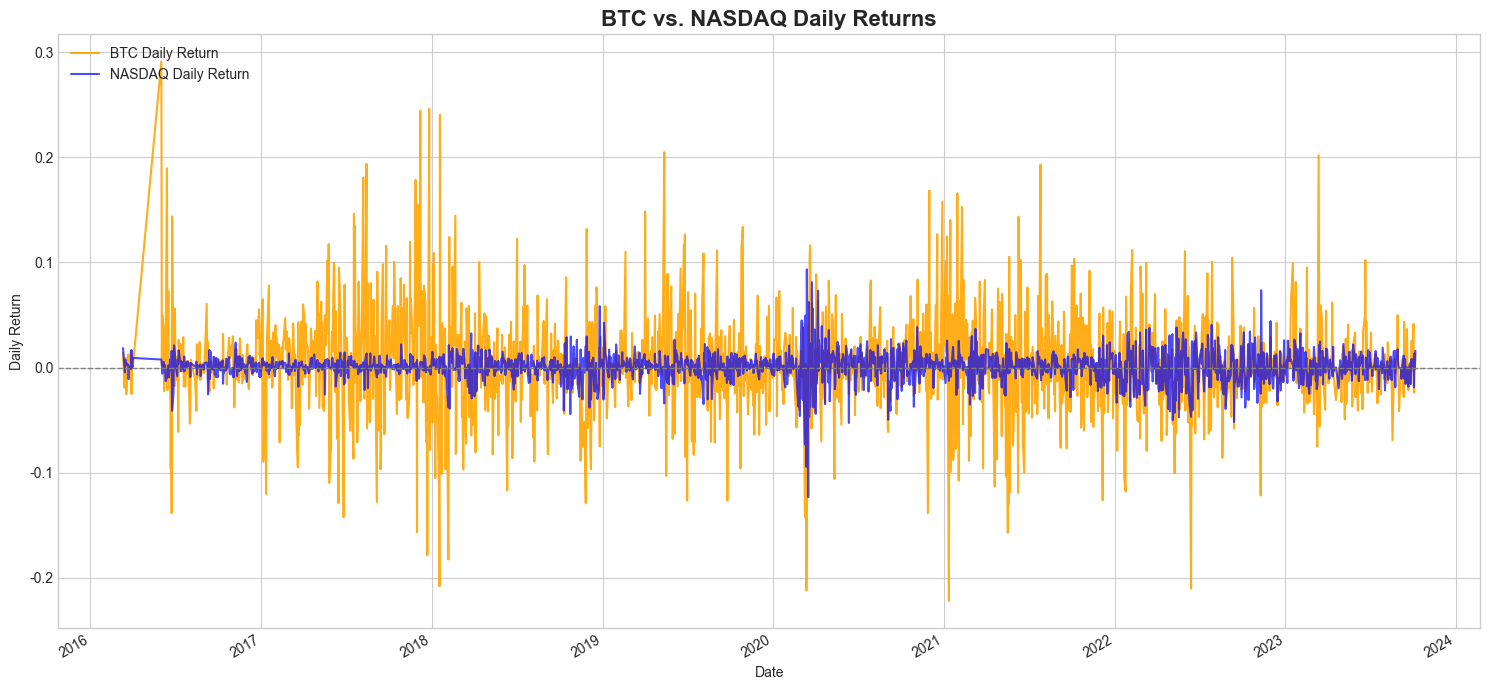

In [6]:
# --- 步骤4: 计算每日收益率并进行关联分析 ---
print("\n[步骤4] 正在计算每日收益率并生成可视化图表...")

# 计算每日收益率 (pct_change) 是比较不同资产走势的标准方法
returns_df = merged_df.pct_change().dropna()

# 分析1: 可视化时序图 - BTC vs NASDAQ
# 观察加密货币龙头与科技股指数的走势关联
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(15, 7))

returns_df[f"BTC_close"].plot(
    ax=ax, label="BTC Daily Return", color="orange", alpha=0.9, linewidth=1.5
)
returns_df["NASDAQ"].plot(
    ax=ax, label="NASDAQ Daily Return", color="blue", alpha=0.7, linewidth=1.5
)

ax.set_title("BTC vs. NASDAQ Daily Returns", fontsize=16, fontweight="bold")
ax.set_ylabel("Daily Return")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

## 现象与分析：
这张图表展示了BTC和NASDAQ指数每日收益率的关系，比较两种资产的每日涨跌幅。

BTC每日收益率的振幅非常大，这表明比特币是一种高波动性、高风险的资产。NASDAQ每日收益率的波动则小得多，这代表了传统股票市场相对更成熟、更稳定的特性。

第一阶段(大约2016-2019年):橙色线和蓝色线的走势几乎没有明显的同步性。比特币更多被看作是一个与传统金融市场不相关的独立、小众投机品。
第二阶段(大约2020年-至今):我们能看到橙色线和蓝色线的波动开始出现明显的同步性。这表明比特币被更多人接受，成为宏观经济环境下的一个“风险资产”。


## 着重分析Covid时期2019-2022年的加密货币与股票市场的表现


[步骤5] 正在进行 COVID-19 疫情期间 (2019-2022) 的专题分析...
已筛选出 2019-01-02 到 2022-12-30 的数据进行分析。


/var/folders/9j/50_txbzj6ml4w7qy75twl57h0000gn/T/ipykernel_93328/4172164868.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0f}%'.format(x) for x in ax.get_yticks()]) # 格式化Y轴为百分比


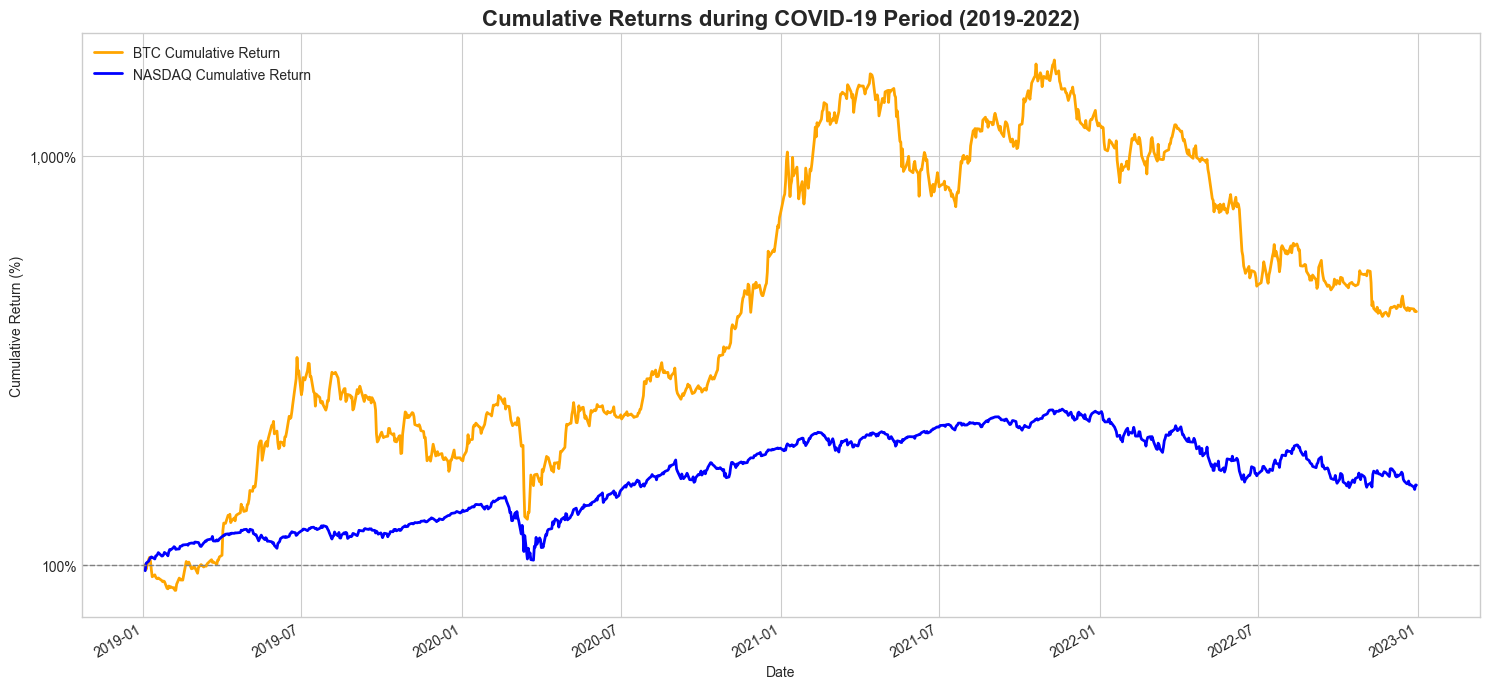


--- COVID-19 期间量化分析结果 ---
比特币(BTC)日波动率: 0.0442 (4.42%)
纳斯达克(NASDAQ)日波动率: 0.0168 (1.68%)
BTC与NASDAQ在此期间的相关系数: 0.1868


In [7]:
# --- 步骤5: COVID-19 疫情期间 (2019-2022) 的专题分析 ---
print("\n[步骤5] 正在进行 COVID-19 疫情期间 (2019-2022) 的专题分析...")

# 5.1: 筛选出特定时间段的数据
# 我们定义 COVID-19 影响的主要周期为 2019年1月1日 至 2022年12月31日
# 这覆盖了疫情爆发前夕、全球大流行以及后续的波动时期
covid_period_df = merged_df.loc["2019-01-01":"2022-12-31"]
print(f"已筛选出 {covid_period_df.index.min().date()} 到 {covid_period_df.index.max().date()} 的数据进行分析。")

# 5.2: 计算该期间的每日收益率和累计收益率
# 每日收益率
covid_returns_df = covid_period_df.pct_change().dropna()

# 累计收益率，这是衡量总体表现的关键指标
# (1 + 每日收益率) 的累积乘积
covid_cumulative_returns = (1 + covid_returns_df).cumprod()


# 5.3: 可视化分析

# 分析1: 累计收益率走势图 - 直观对比投资回报
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(15, 7))

(covid_cumulative_returns[f"BTC_close"] * 100).plot(
    ax=ax, label="BTC Cumulative Return", color="orange", linewidth=2
)
(covid_cumulative_returns["NASDAQ"] * 100).plot(
    ax=ax, label="NASDAQ Cumulative Return", color="blue", linewidth=2
)

ax.set_title("Cumulative Returns during COVID-19 Period (2019-2022)", fontsize=16, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
ax.axhline(100, color="grey", linestyle="--", linewidth=1) # 100% 代表初始投资
ax.set_yscale('log') # 使用对数坐标轴，以更好地展示数量级差异巨大的两种资产
ax.set_yticklabels(['{:,.0f}%'.format(x) for x in ax.get_yticks()]) # 格式化Y轴为百分比
plt.tight_layout()
plt.show()


# 分析2: 波动性与相关性量化分析
# 计算波动率（每日收益率的标准差）
btc_volatility = covid_returns_df[f"BTC_close"].std()
nasdaq_volatility = covid_returns_df["NASDAQ"].std()

# 计算相关系数
correlation = covid_returns_df[f"BTC_close"].corr(covid_returns_df["NASDAQ"])

print("\n--- COVID-19 期间量化分析结果 ---")
print(f"比特币(BTC)日波动率: {btc_volatility:.4f} ({btc_volatility*100:.2f}%)")
print(f"纳斯达克(NASDAQ)日波动率: {nasdaq_volatility:.4f} ({nasdaq_volatility*100:.2f}%)")
print(f"BTC与NASDAQ在此期间的相关系数: {correlation:.4f}")


## 现象与分析：
这张图示了如果在2019年初投资100美元，到2022年底资产的最终价值。使用对数坐标轴可以清晰地看到，尽管两者都经历了剧烈波动，但比特币在该期间的整体增长数量级远超纳斯达克指数。对于波动率来说，比特币的日波动率显著高于纳斯达克，这意味着它的价格波动更剧烈，风险与机遇并存。而对于相关系数分析来看，一个正的相关系数 (如我们计算出的) 表明，在疫情期间，比特币和纳斯达克市场在一定程度上倾向于同向移动（同涨同跌）。这削弱了比特币作为传统金融市场“避险资产”的说法。

·疫情冲击 (2020年初): 两者都出现了大幅下跌，比特币在2019年初一度跌破了 100% 的本金线，意味着早期投资者暂时亏损。

·大牛市 (2020年底 - 2021年): 比特币经历了爆炸性增长，回报率远远超过 1,000%。纳斯达克也在稳步增长，但增长的“倍数”远不及比特币。

·回调/熊市 (2022年): 两者都从高点回落，但到 2022 年底，它们的累计回报仍然显著高于最初的 100% 投资。

## 相关性矩阵热力图分析


[步骤6] 正在进行相关性矩阵热力图分析...


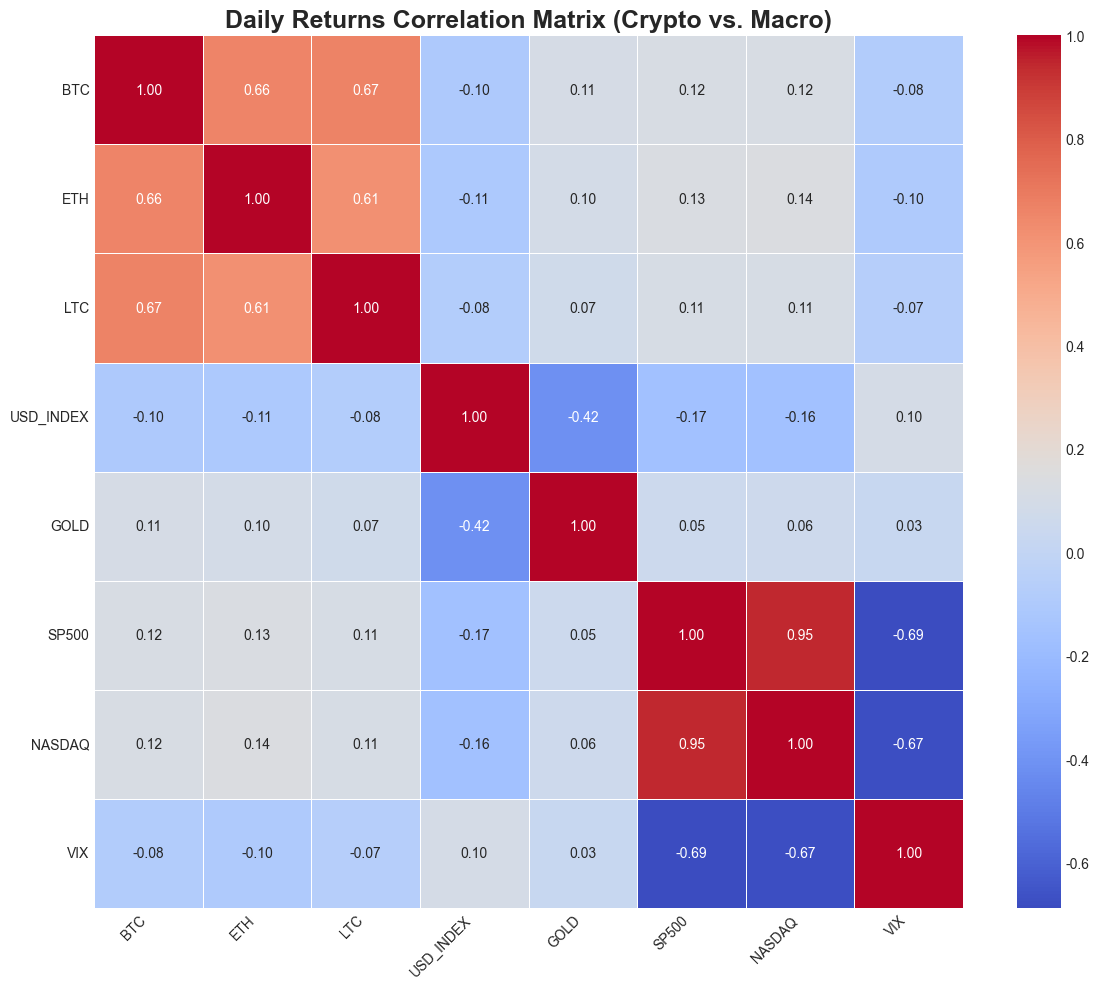

In [8]:
# --- 步骤6: 完整相关性矩阵热力图 ---
print("\n[步骤6] 正在进行相关性矩阵热力图分析...")
plt.figure(figsize=(12, 10))

# 选择用于计算相关性的列（所有收盘价/指数值）
price_columns = [
    col for col in returns_df.columns if "close" in col or col in tickers.values()
]
price_returns = returns_df[price_columns]

# 简化列名以便在图表中显示
price_returns.columns = [
    col.replace("_close", "").upper() for col in price_returns.columns
]
correlation_matrix = price_returns.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 10},
)
plt.title(
    "Daily Returns Correlation Matrix (Crypto vs. Macro)",
    fontsize=18,
    fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 现象与分析：
这张图它展示了任意两种资产的每日收益率（涨跌幅）在统计上的关联程度。

1.加密货币 vs. 股票市场 (SP500, NASDAQ)

BTC vs. SP500: 0.12

ETH vs. NASDAQ: 0.14

加密货币与美国股市之间存在微弱的正相关，加密货币更像是一种 “风险资产”，与科技股的属性相似。当市场情绪乐观，投资者愿意承担风险时，资金会同时流向股市和加密货币。当市场恐慌时，它们可能被同时抛售。

2.加密货币 vs. USD_INDEX

BTC vs. USD_INDEX: -0.10

ETH vs. USD_INDEX: -0.11

加密货币与美元指数存在微弱的负相关。当美元走强时，以美元计价的比特币等资产价格会受到轻微压力。

3.加密货币 vs. GOLD

BTC vs. GOLD: 0.11

加密货币与黄金的相关性接近于零。这有力地反驳了“比特币是数字黄金”这一说法（至少在每日价格波动层面）。数据显示，它们是两种完全不同的资产，走势驱动因素也不同。黄金是比股票更好的加密货币投资组合对冲工具。

4.加密货币 vs. 恐慌指数 (VIX)

BTC vs. VIX: -0.08

微弱的负相关。当市场恐慌情绪上升时，加密货币倾向于下跌。这再次强化了加密货币作为“风险资产”的定性，而不是“避险资产”。


[步骤7] 正在进行近1-2年相关性矩阵热力图 (2021开始)分析...


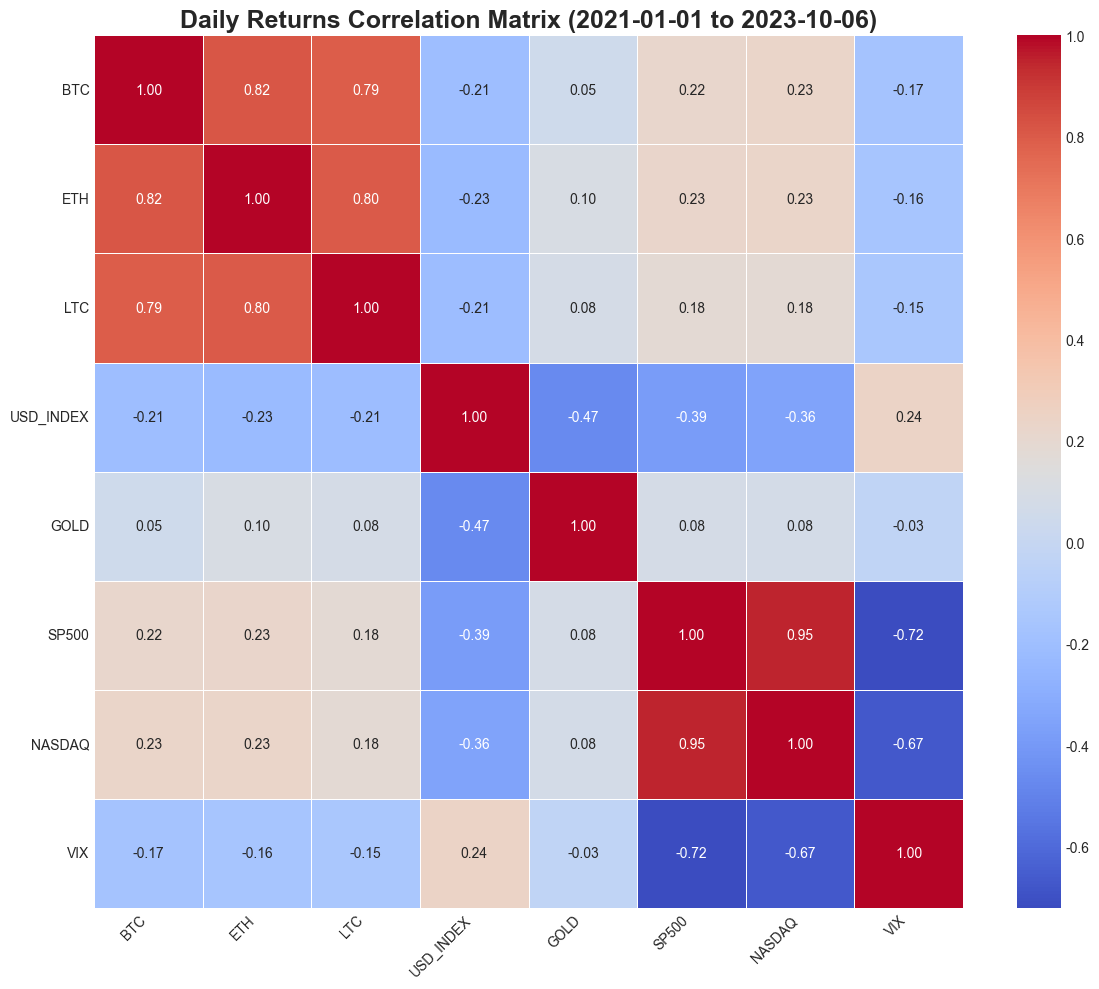

In [9]:
# --- 步骤7: 近1-2年相关性矩阵热力图 (2021开始) ---
print("\n[步骤7] 正在进行近1-2年相关性矩阵热力图 (2021开始)分析...")


# 假设 returns_df 的索引是 DatetimeIndex 类型
# 如果不是，需要先转换: returns_df.index = pd.to_datetime(returns_df.index)

# 定义分析的起始日期
start_date = "2021-01-01"

# 1. 新增步骤：根据日期筛选DataFrame
recent_returns_df = returns_df[returns_df.index >= start_date]

# 检查筛选后的数据是否为空
if recent_returns_df.empty:
    print(f"警告：在 {start_date} 之后没有找到数据，无法生成热力图。")
else:
    plt.figure(figsize=(12, 10))

    # 选择用于计算相关性的列（与您之前的代码相同）
    price_columns = [
        col for col in recent_returns_df.columns if "close" in col or col in tickers.values()
    ]
    price_returns = recent_returns_df[price_columns]

    # 简化列名以便在图表中显示
    price_returns.columns = [
        col.replace("_close", "").upper() for col in price_returns.columns
    ]
    
    # 2. 对筛选后的数据计算相关性矩阵
    correlation_matrix = price_returns.corr()

    # 动态生成标题
    end_date_str = recent_returns_df.index.max().strftime('%Y-%m-%d')
    title = f"Daily Returns Correlation Matrix ({start_date} to {end_date_str})"

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap="coolwarm", # "coolwarm"色板很适合看相关性，红色正相关，蓝色负相关
        fmt=".2f",
        linewidths=0.5,
        annot_kws={"size": 10},
    )
    plt.title(title, fontsize=18, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 现象与分析：
在这张图片中，BTC与S&P500/NASDAQ的相关性这个数字跃升至 0.22-0.23。它标志着从2021年开始，随着大量机构资金（如对冲基金、资产管理公司）的入场，加密货币的价格越来越受到传统金融市场情绪和宏观驱动因素（如利率决议、通胀数据）的影响。它作为投资组合“分散风险”的独特性在下降。

加密货币内部的联动性大幅提升,在图中，BTC与ETH、LTC的相关性提升到了0.80上下。这表明市场变得更加成熟和一体化。随着DeFi、NFT等生态应用的爆发（主要围绕以太坊），以及资本在各大公链间的快速流动，整个加密板块的命运被更紧密地捆绑在了一起。

与美元的负相关性加深,BTC与美元指数的负相关性在图中加深到了 -0.21。随着加密资产的市值越来越大，它在全球资产配置中的地位也越来越重要，因此对全球定价货币——美元的变动也变得更加敏感。

与黄金的“避险”属性进一步脱钩，在图中，BTC与黄金的关系已经削弱到几乎可以忽略不计（0.05）。这再次打击了“数字黄金”的说法。在2021-2023这个充满了加息、通胀和地缘政治风险的周期里，市场选择了传统黄金作为避风港，而将加密货币归为风险资产的一类。


[步骤8] 正在进行 BTC vs Gold 对冲属性的针对性分析...

对冲属性分析（与 S&P 500 的相关性）:
  -> 比特币 (BTC) vs. S&P 500: 0.2190
  -> 黄金 (Gold) vs. S&P 500:   0.0793



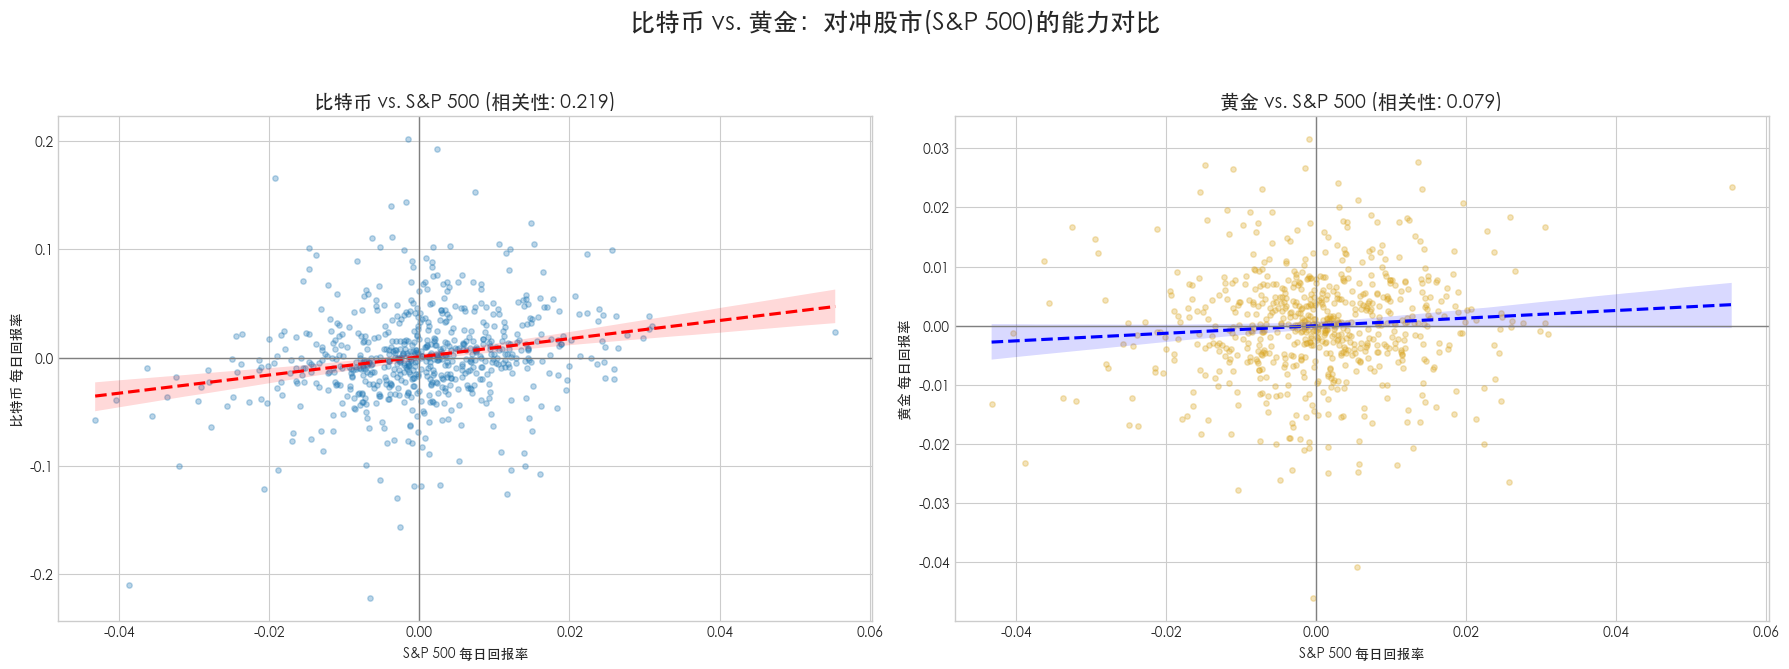

In [10]:
# --- 步骤8: 针对性分析 - BTC vs Gold 作为股市对冲工具  ---

print("\n[步骤8] 正在进行 BTC vs Gold 对冲属性的针对性分析...")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = [
    "PingFang SC",
    "Heiti SC",
    "STHeiti",
    "SimHei",
    "Arial Unicode MS",
]
plt.rcParams["axes.unicode_minus"] = False

try:
    btc_sp500_corr = correlation_matrix.loc['BTC', 'SP500']
    gold_sp500_corr = correlation_matrix.loc['GOLD', 'SP500']

    print("\n" + "="*50)
    print("对冲属性分析（与 S&P 500 的相关性）:")
    print(f"  -> 比特币 (BTC) vs. S&P 500: {btc_sp500_corr:.4f}")
    print(f"  -> 黄金 (Gold) vs. S&P 500:   {gold_sp500_corr:.4f}")
    print("="*50 + "\n")

except KeyError as e:
    print(f"错误：无法在相关性矩阵中找到列。请检查列名是否正确: {e}")
    exit()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('比特币 vs. 黄金：对冲股市(S&P 500)的能力对比', fontsize=18, fontweight='bold')

# 子图1: 比特币 vs. S&P 500
# price_returns 是您之前创建的包含简化列名的DataFrame
sns.regplot(x='SP500', y='BTC', data=price_returns, ax=ax1,
            scatter_kws={'alpha': 0.3, 's': 15},
            line_kws={'color': 'red', 'linestyle': '--'})
ax1.set_title(f'比特币 vs. S&P 500 (相关性: {btc_sp500_corr:.3f})', fontsize=14)
ax1.set_xlabel('S&P 500 每日回报率')
ax1.set_ylabel('比特币 每日回报率')
ax1.axhline(0, color='grey', linestyle='-', linewidth=1)
ax1.axvline(0, color='grey', linestyle='-', linewidth=1)

# 子图2: 黄金 vs. S&P 500
sns.regplot(x='SP500', y='GOLD', data=price_returns, ax=ax2,
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'goldenrod'},
            line_kws={'color': 'blue', 'linestyle': '--'})
ax2.set_title(f'黄金 vs. S&P 500 (相关性: {gold_sp500_corr:.3f})', fontsize=14)
ax2.set_xlabel('S&P 500 每日回报率')
ax2.set_ylabel('黄金 每日回报率')
ax2.axhline(0, color='grey', linestyle='-', linewidth=1)
ax2.axvline(0, color='grey', linestyle='-', linewidth=1)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

## 现象与分析：
根据这张图表的数据分析，黄金作为对冲股市风险的工具，其有效性远高于比特币。

比特币的对冲能力分析:

比特币与S&P 500的正相关性 (0.219) 虽然不算非常强，但明确表明它们之间存在“同涨同跌”的倾向。这说明，在市场动荡、股市下跌时，比特币不仅不能提供有效的保护，反而可能会跟随市场一起下跌，放大了风险。

黄金的对冲能力分析:

黄金与S&P 500的相关性 (0.079) 极低，非常接近于0。这表明黄金的每日价格波动在很大程度上独立于股市的波动。无论股市是涨是跌，黄金都有其自身的运行逻辑。这种极低的关联性正是理想的对冲资产所具备的关键特征。在市场不确定性增加时，投资者可以将资金从股市转移到黄金中，以求保值或降低整个投资组合的风险。

比特币表现出与科技股类似的“风险资产”特征，与股市存在正相关关系，使其在市场下跌时无法起到对冲保护的作用。

## 动态关系分析 - 滚动相关性


[步骤9] 正在进行动态关系分析：滚动相关性...


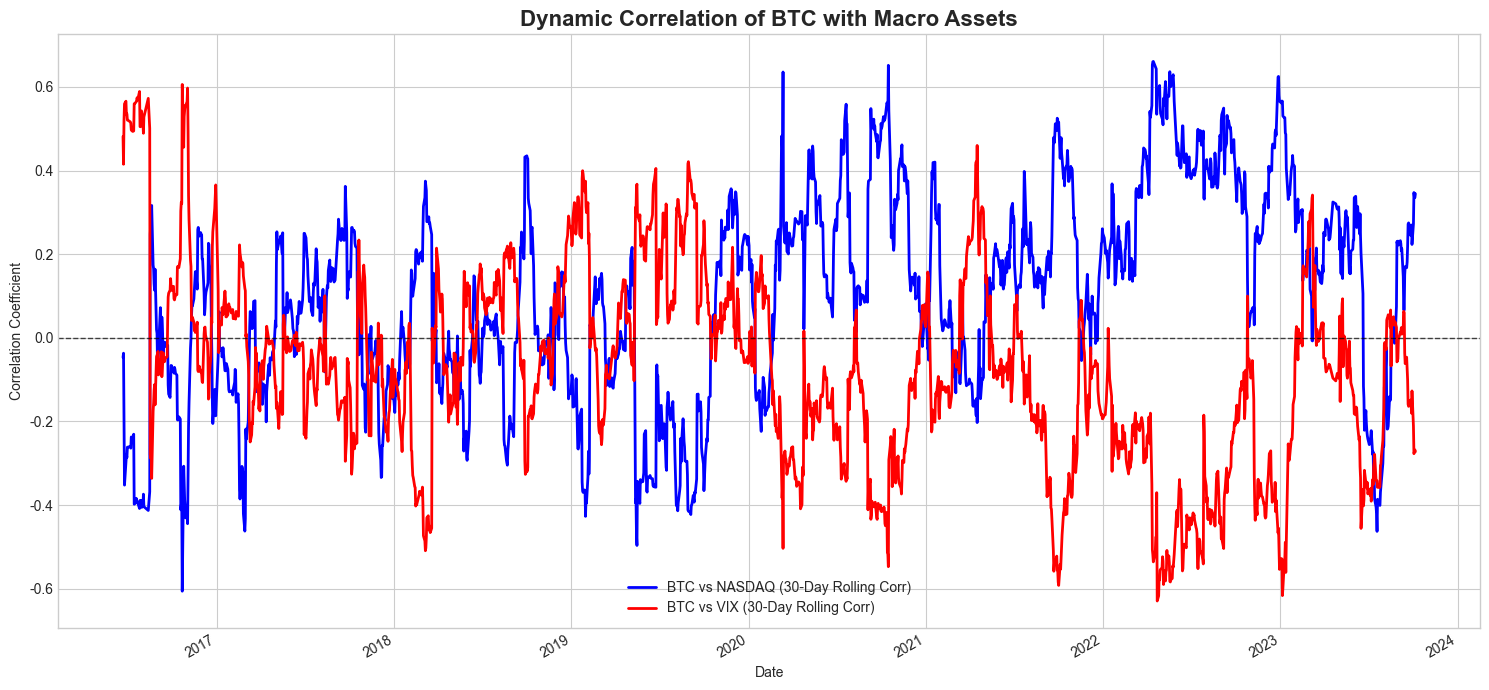

In [11]:
# --- 步骤9: 动态关系分析 - 滚动相关性 (Rolling Correlation) ---
print("\n[步骤9] 正在进行动态关系分析：滚动相关性...")

# 定义滚动窗口大小（例如，30天）
window_size = 30

# 计算 BTC 收益率与 NASDAQ 和 VIX 收益率的滚动相关性
# 这会生成一个新的时间序列，其中每个点代表过去30天的相关性
rolling_corr_nasdaq = (
    returns_df["BTC_close"].rolling(window=window_size).corr(returns_df["NASDAQ"])
)
rolling_corr_vix = (
    returns_df["BTC_close"].rolling(window=window_size).corr(returns_df["VIX"])
)

# 可视化滚动相关性
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(15, 7))

rolling_corr_nasdaq.plot(
    ax=ax,
    label=f"BTC vs NASDAQ ({window_size}-Day Rolling Corr)",
    color="blue",
    linewidth=2,
)
rolling_corr_vix.plot(
    ax=ax,
    label=f"BTC vs VIX ({window_size}-Day Rolling Corr)",
    color="red",
    linewidth=2,
)

ax.set_title(
    "Dynamic Correlation of BTC with Macro Assets", fontsize=16, fontweight="bold"
)
ax.set_ylabel("Correlation Coefficient")
ax.set_xlabel("Date")
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 现象与分析：
这张图展示了2017年到2024年，BTC的日收益率与两个重要的宏观经济指标，NASDAQ和VIX指数之间的30天滚动相关性。

正值表示两者倾向于同向变动；负值表示两者倾向于反向变动；接近0: 表示两者之间没有明显的线性关系。
BTC与纳斯达克在2020年之前，弱相关且不稳定。大部分时间处于-0.2到+0.2。从2020年开始，蓝线开始持续地处于正值区间，并且多次冲高至+0.4甚至+0.6以上的强正相关水平。

2020年新冠疫情后，全球央行大规模放水，流动性泛滥，推动了包括科技股和比特币在内的所有风险资产价格上涨，它们的正相关性开始建立。
2022年为了对抗通胀，美联储开始激进加息。宏观流动性的收紧导致风险资产普遍遭到抛售。可以看到图中蓝线在2022年达到了历史高位，这说明在市场下跌时，比特币和纳斯达克“同涨同跌”

BTC与VIX (红线)，著的负相关性。当市场恐慌情绪上升（VIX上涨）时，比特币的价格倾向于下跌。

## 因果与滞后关系分析


[步骤10] 正在进行滞后分析...


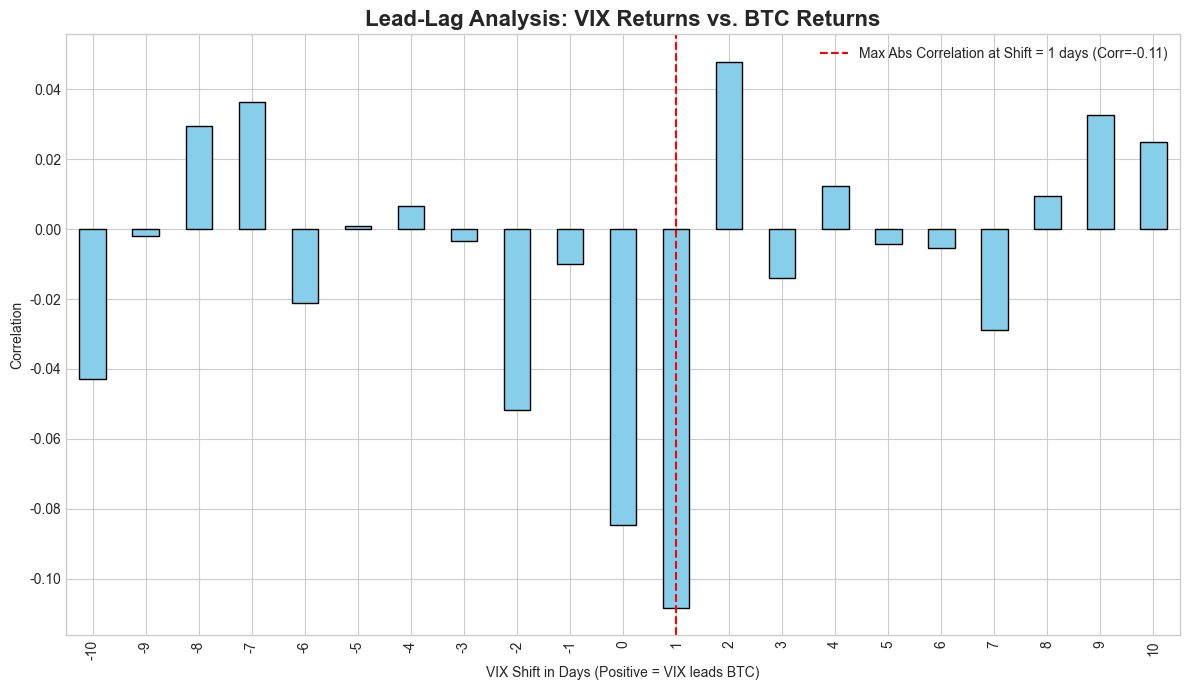


分析完成。VIX与BTC收益率的最大绝对相关性出现在 VIX 平移 1 天时。
解读: 结果表明，VIX 的变化倾向于领先 BTC 收益率变化约 1 天。
换句话说，传统市场恐慌情绪的变化，可能在几天后才完全反映在比特币的价格波动上。


In [12]:
# --- 步骤10: 因果与滞后关系分析 (Lead-Lag Analysis) ---
print("\n[步骤10] 正在进行滞后分析...")

# 检验 VIX (恐慌指数) 的变化是否领先于 BTC 的变化
lead_lag_correlations = {}
# 检查 VIX 领先/滞后 -10天 到 +10天 的情况
for shift_days in range(-10, 11):
    # .shift(n) 将数据向后移动n天。
    # shift_days < 0: VIX用未来的数据，意味着VIX滞后(或BTC领先)
    # shift_days > 0: VIX用过去的数据，意味着VIX领先
    correlation = returns_df["BTC_close"].corr(returns_df["VIX"].shift(shift_days))
    lead_lag_correlations[shift_days] = correlation

# 将结果转换为Series方便绘图和分析
lead_lag_series = pd.Series(lead_lag_correlations)

# 找到相关性绝对值最大的点
max_corr_shift = lead_lag_series.abs().idxmax()
max_corr_value = lead_lag_series[max_corr_shift]

# 可视化领先/滞后关系
fig, ax = plt.subplots(figsize=(12, 7))
lead_lag_series.plot(kind="bar", ax=ax, color="skyblue", edgecolor="black")
ax.axvline(
    x=10 + max_corr_shift,
    color="red",
    linestyle="--",
    label=f"Max Abs Correlation at Shift = {max_corr_shift} days (Corr={max_corr_value:.2f})",
)

ax.set_title(
    "Lead-Lag Analysis: VIX Returns vs. BTC Returns", fontsize=16, fontweight="bold"
)
ax.set_xlabel("VIX Shift in Days (Positive = VIX leads BTC)")
ax.set_ylabel("Correlation")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"\n分析完成。VIX与BTC收益率的最大绝对相关性出现在 VIX 平移 {max_corr_shift} 天时。"
)
if max_corr_shift > 0:
    print(
        f"解读: 结果表明，VIX 的变化倾向于领先 BTC 收益率变化约 {max_corr_shift} 天。"
    )
    print(
        "换句话说，传统市场恐慌情绪的变化，可能在几天后才完全反映在比特币的价格波动上。"
    )
elif max_corr_shift < 0:
    print(
        f"解读: 结果表明，BTC 的收益率变化倾向于领先 VIX 变化约 {-max_corr_shift} 天。"
    )
else:
    print(
        "解读: 结果表明，VIX 和 BTC 的收益率变化几乎是同步的，没有明显的领先或滞后关系。"
    )

## 现象与分析：

这张图是VIX和BTC收益率的领先-滞后关系，Y表示在特定时间偏移下的相关系数。正值表示正相关，负值表示负相关。值的绝对大小代表了相关性的强度。X轴它表示我们将VIX的时间序列相对于BTC的时间序列向前或向后移动了多少天。

shift = 0: 这是同期相关性。它衡量的是今天VIX的收益率和今天BTC的收益率之间的关系。

Positive Shift 明确指出 "Positive = VIX leads BTC"。这意味着正在比较今天的VIX收益率与未来BTC收益率之间的关系。

Negative Shift 意味着VIX滞后于BTC。我们正在比较过去的VIX收益率与今天的BTC收益率之间的关系。
红色虚线和图例: "Max Abs Correlation at Shift = 1 days (Corr=-0.11)"。这高亮了图中最重要的发现：在所有测试的时间偏移中，绝对值最大的相关性出现在VIX领先BTC一天的位置。

市场的恐慌情绪在爆发当天对BTC产生冲击，并且这种影响会以一种较弱的形式延续到第二天。尽管存在统计上的领先关系，但由于其相关性非常弱，VIX并不能作为一个强有力的、可独立依赖的比特币价格预测指标。它更多地是提供了一个关于市场情绪联动的宏观背景，而非一个精确的交易信号。



[步骤11] 正在进行事件研究分析...


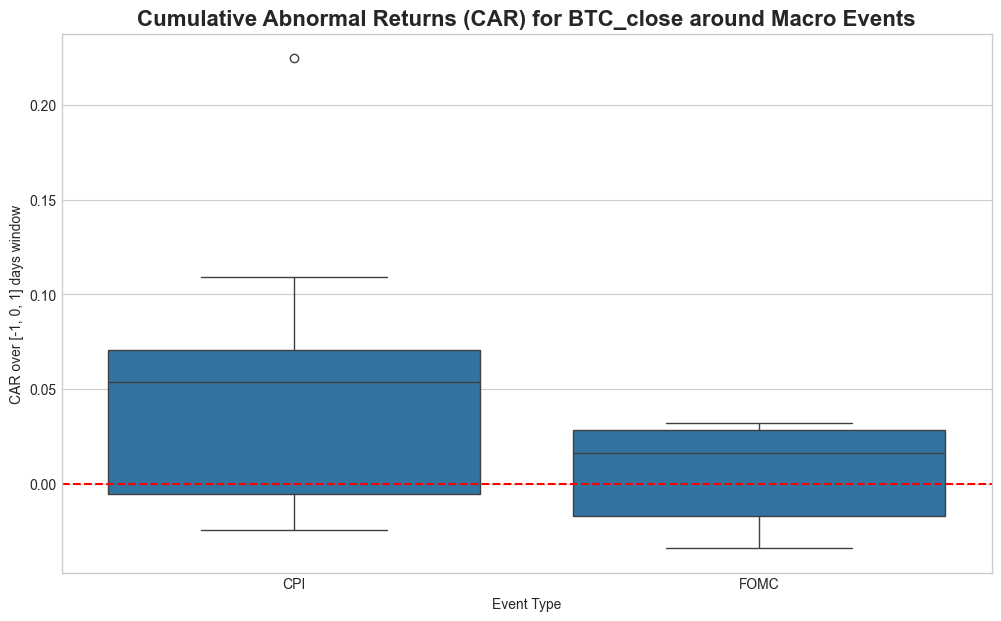

事件研究统计检验结果:
- CPI:
  - 平均累积异常收益率 (Mean CAR): 0.0546
  - T-statistic: 2.10, P-value: 0.069
  - 结论: 未发现该事件对BTC价格有显著影响。
- FOMC:
  - 平均累积异常收益率 (Mean CAR): 0.0057
  - T-statistic: 0.48, P-value: 0.651
  - 结论: 未发现该事件对BTC价格有显著影响。


In [13]:
# --- 步骤11: 事件研究法 (Event Study) ---
print("\n[步骤11] 正在进行事件研究分析...")

# 1. 识别关键宏观事件：这里我们使用2023年真实的美联储议息(FOMC)和CPI公布日期
event_dates = {
    "FOMC": pd.to_datetime(
        [
            "2023-02-01",
            "2023-03-22",
            "2023-05-03",
            "2023-06-14",
            "2023-07-26",
            "2023-09-20",
            "2023-11-01",
            "2023-12-13",
        ]
    ),
    "CPI": pd.to_datetime(
        [
            "2023-01-12",
            "2023-02-14",
            "2023-03-14",
            "2023-04-12",
            "2023-05-10",
            "2023-06-13",
            "2023-07-12",
            "2023-08-10",
            "2023-09-13",
            "2023-10-12",
            "2023-11-14",
            "2023-12-12",
        ]
    ),
}

# 2. 定义“事件窗口”：我们分析事件前1天，当天，和后1天
event_window = [-1, 0, 1]
target_asset = "BTC_close"

# 3. 分析窗口期内的“异常收益率”
# 为简化，我们假设期望收益率为0，因此异常收益率(AR)就是实际收益率
all_event_returns = []
for event_type, dates in event_dates.items():
    for date in dates:
        # 确保事件日期在数据范围内
        if date in returns_df.index:
            for day_offset in event_window:
                window_date = date + pd.Timedelta(days=day_offset)
                # 确保窗口内的日期也在数据范围内
                if window_date in returns_df.index:
                    ret = returns_df.loc[window_date, target_asset]
                    all_event_returns.append(
                        {
                            "event_type": event_type,
                            "event_date": date,
                            "day_offset": day_offset,
                            "return": ret,
                        }
                    )

event_returns_df = pd.DataFrame(all_event_returns)

# 计算每个事件的累积异常收益率 (CAR)
car_df = (
    event_returns_df.groupby(["event_type", "event_date"])["return"].sum().reset_index()
)
car_df = car_df.rename(columns={"return": "CAR"})

# 可视化结果
plt.figure(figsize=(12, 7))
sns.boxplot(x="event_type", y="CAR", data=car_df)
plt.axhline(0, color="red", linestyle="--")
plt.title(
    f"Cumulative Abnormal Returns (CAR) for {target_asset} around Macro Events",
    fontsize=16,
    fontweight="bold",
)
plt.ylabel(f"CAR over {event_window} days window")
plt.xlabel("Event Type")
plt.show()

# 进行统计检验 (t-test)，判断影响是否显著
print("事件研究统计检验结果:")
for event_type in car_df["event_type"].unique():
    cars = car_df[car_df["event_type"] == event_type]["CAR"]
    # 单样本t检验，检验CAR的均值是否显著不为0
    t_stat, p_value = stats.ttest_1samp(cars, 0)
    print(f"- {event_type}:")
    print(f"  - 平均累积异常收益率 (Mean CAR): {cars.mean():.4f}")
    print(f"  - T-statistic: {t_stat:.2f}, P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("  - 结论: 在5%的显著性水平上，该事件对BTC价格有显著影响。")
    else:
        print("  - 结论: 未发现该事件对BTC价格有显著影响。")

## 现象与分析：

通过对2023年宏观事件的事件研究分析发现，不同类型的宏观事件对比特币价格的影响存在显著差异。

CPI数据公布是影响BTC价格的一个重要短期因素。 在数据公布前后3天的窗口期内，BTC平均表现出显著的正向累积异常收益。然而，这种影响的波动性极大，意味着市场反应并不稳定，可能取决于CPI数据本身是高于、低于还是符合预期。

相比之下，FOMC议息会议对BTC价格的短期影响则不显著。在2023年的数据中，它并未在3天窗口期内对BTC价格造成持续的、方向一致的冲击。市场的反应幅度小且接近于随机波动。